In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# ---------------------------------------------------------
# DATA PREPARATION
# ---------------------------------------------------------

# Load data
patients = pd.read_csv('patients.csv')
plans = pd.read_csv('treatment_plans.csv')
sessions = pd.read_csv('session_logs.csv')
assessments = pd.read_csv('clinical_assessments.csv')

In [3]:
# Create new table with patient total and completed sessions
adherence = sessions.groupby(by='plan_id', as_index=False).agg(
    total_sessions=('session_id', 'count'),
    completed_sessions=('completed', 'sum')
)

# Calculate patient-level adherence rate
adherence['adherence_rate'] = (adherence['completed_sessions'] / adherence['total_sessions']) * 100

# Insert patient_id column from the plans dataframe
adherence = adherence.merge(plans[['plan_id', 'patient_id']], on='plan_id')

In [4]:
adherence.head()

,plan_id,total_sessions,completed_sessions,adherence_rate,patient_id
0,1000,24,20,83.333333,1
1,1001,24,14,58.333333,2
2,1002,24,7,29.166667,3
3,1003,24,23,95.833333,4
4,1004,24,19,79.166667,5


In [5]:
# Calculate pain score drop (baseline - final)
pivot_assessments = assessments.pivot(index='patient_id', columns='assessment_type', values='pain_score').reset_index()
pivot_assessments['pain_reduction'] = pivot_assessments['Baseline'] - pivot_assessments['Final']

# Merge into master dataframe and categorize each patient as a high or low adherence member
master_df = adherence.merge(pivot_assessments, on='patient_id')
master_df['cohort'] = np.where(master_df['adherence_rate'] >= 70, 'High Adherence (>=70%)', 'Low Adherence (<70%)')

In [6]:
master_df.head()

,plan_id,total_sessions,completed_sessions,adherence_rate,patient_id,Baseline,Final,pain_reduction,cohort
0,1000,24,20,83.333333,1,9,2,7,High Adherence (>=70%)
1,1001,24,14,58.333333,2,8,1,7,Low Adherence (<70%)
2,1002,24,7,29.166667,3,6,5,1,Low Adherence (<70%)
3,1003,24,23,95.833333,4,9,2,7,High Adherence (>=70%)
4,1004,24,19,79.166667,5,8,1,7,High Adherence (>=70%)


In [7]:
# Segregate patients by high or low adherence rate
high_group = master_df[master_df['cohort'] == 'High Adherence (>=70%)']['pain_reduction']
low_group = master_df[master_df['cohort'] == 'Low Adherence (<70%)']['pain_reduction']

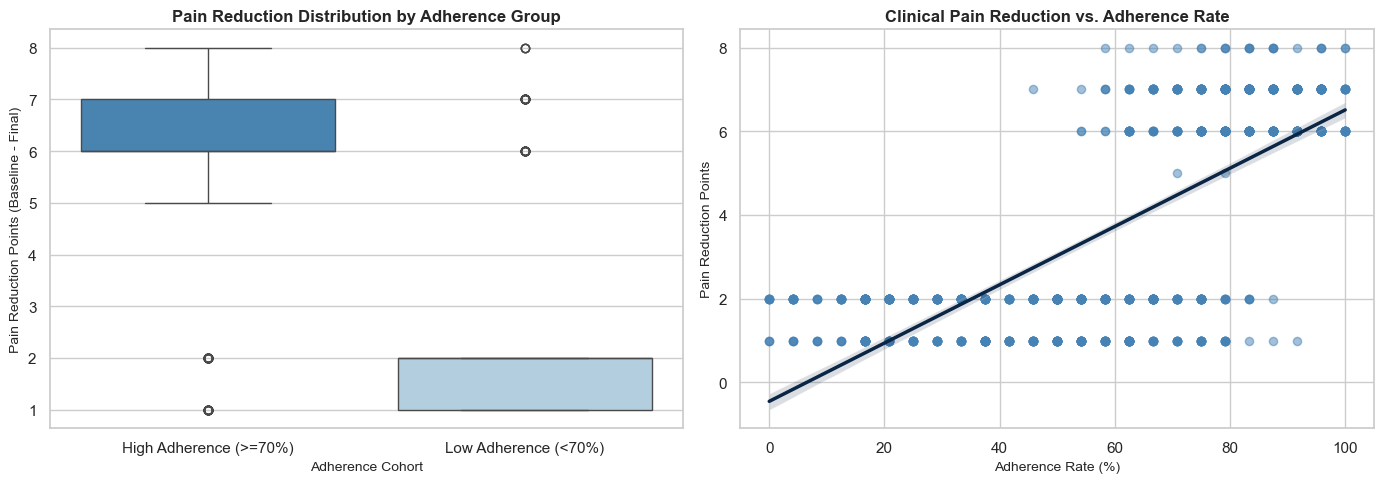

In [8]:
# ---------------------------------------------------------
# SEABORN VISUALIZATION
# ---------------------------------------------------------

# Define seaborn theme
sns.set_theme(style="whitegrid")

# Create figure with 2 side-by-side plots (1 row; 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot of Pain Reduction by Cohort
sns.boxplot(
    ax=axes[0],
    data=master_df,
    x='cohort', 
    y='pain_reduction',
    hue='cohort',
    palette='Blues_r'
)
axes[0].set_title('Pain Reduction Distribution by Adherence Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Adherence Cohort', fontsize=10)
axes[0].set_ylabel('Pain Reduction Points (Baseline - Final)', fontsize=10)

# Plot 2: Scatterplot with Linear Regression Line
sns.regplot(
    ax=axes[1],
    data=master_df,
    x='adherence_rate',
    y='pain_reduction',
    scatter_kws={'color': '#4682B4', 'alpha': 0.5, 's': 35},
    line_kws={'color': '#0B2545', 'linewidth': 2.5}
)
axes[1].set_title('Clinical Pain Reduction vs. Adherence Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Adherence Rate (%)', fontsize=10)
axes[1].set_ylabel('Pain Reduction Points', fontsize=10)

plt.tight_layout()
plt.savefig('seaborn_adherence_analysis.png', dpi=300)

plt.show()

In [9]:
# ---------------------------------------------------------
# STATISTICAL ANALYSIS
# ---------------------------------------------------------

#Given N=1000, the Central Limit Theorem applies, ensuring the sampling distribution of the mean is normal.
#The Welch's t-test was applied to handle potential variance heterogeneity.
t_stat, p_val = stats.ttest_ind(high_group, low_group, equal_var=False)

print("HYPOTHESIS TESTING RESULTS")
print(f"High Adherence Mean Pain Reduction: {high_group.mean():.2f} points")
print(f"Low Adherence Mean Pain Reduction: {low_group.mean():.2f} points")
print(f"t-statistic: {t_stat:.4f}")
print("p-value: P < 0.001" if p_val < 0.001 else f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Reject H0 — Statistically significant difference confirmed!")
else:
    print("Result: Fail to reject H0.")

HYPOTHESIS TESTING RESULTS
High Adherence Mean Pain Reduction: 5.79 points
Low Adherence Mean Pain Reduction: 2.04 points
t-statistic: 33.5352
p-value: P < 0.001
Result: Reject H0 — Statistically significant difference confirmed!


In [10]:
#Calculate Pearson Correlation Coefficient
corr, corr_p = stats.pearsonr(master_df['adherence_rate'], master_df['pain_reduction'])
print(f"Pearson Correlation (Pain Reduction vs Adherence): r = {corr:.3f} (p = {corr_p:.4e})")

Pearson Correlation (Pain Reduction vs Adherence): r = 0.724 (p = 2.4853e-163)
